# Supplementary Figure S36: `s36_controversial`

This notebook rebuilds the figure step by step from its script, `figures/supplementary/sup_controversial.py`. Every code cell below is a verbatim slice of that file, in the order the file defines it: first the imports and configuration, then each helper function with a short explanation, then the body of `main()` laid out as the assembly of the panels, and finally the rendered figure with its caption. Run the cells top to bottom; in the reference environment the PNG written at the end is identical to the submitted manuscript file (see docs/REPRODUCIBILITY.md).

The controversial-accentuation experiment forces two encoding models to disagree. For each of seven aIT sites in Monkey R, images were synthesized to drive ResNet50's predicted response while suppressing ResNet50-Robust's, and vice versa, then shown back to the animal. Panel A is a procedure schematic, panel B shows example stimuli for four sites around a prediction-space scatter, panel C plots model prediction against measured response for three sites, and panel D summarizes the per-site correlations for both models. Neural responses are standardized trial averages from the loader's controversial table; the stimulus images are raw experiment inputs.

## What the script says about itself

Supp fig (controversial) - synthetic-controversial experiment, red monkey (aIT).

Images synthesized to DRIVE one encoding model's prediction while SUPPRESSING the other's (ResNet50 vs RN50-Robust), then shown back to the animal.

- **(a)** Procedure schematic flanked by the two models' stimulus goals.
- **(b)** ResNet50-preferring mosaic | prediction-space scatter | RN50-Robust-preferring mosaic (4 example units, shared seed columns ranked by mean controversy).
- **(c)** 3 example units - model prediction vs measured neural response, ResNet50 (orange) + RN50-Robust (green) fits with per-unit correlations.
- **(d)** Per-unit r summary (ResNet50 vs RN50-Robust), paired lines + mean diamonds + Wilcoxon signed-rank across the 7 targeted units.

Neural = anchorDay-standardized trial averages via loader.load_controversial_table(); stimulus PNGs from data/stimuli_controversial/ (irreducible experiment input). Fixed 180 x 150 mm canvas (no tight bbox).

## 1. Environment

A few lines that are not in the script: they make the notebook render exactly like the command-line harness does (single-threaded BLAS, the Agg backend with matplotlib defaults, the repository on the import path) and check that the preprocessed data are present.

In [1]:
import os, sys
from pathlib import Path

# Keep BLAS single-threaded: multithreaded OpenMP together with torch can kill the kernel on macOS.
for _v in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS', 'VECLIB_MAXIMUM_THREADS'):
    os.environ.setdefault(_v, '1')
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

# Render with the Agg backend and matplotlib's defaults, exactly like the figure scripts;
# Jupyter's inline backend would otherwise change dpi and bounding boxes.
os.environ['MPLBACKEND'] = 'Agg'
import matplotlib; matplotlib.use('Agg'); matplotlib.rcdefaults()

# Work from the repository root whether the notebook is opened there or in notebooks/figures/.
REPO = Path.cwd() if (Path.cwd() / 'pnc').exists() else Path.cwd().parents[1]
sys.path.insert(0, str(REPO))
from pnc import paths

# The figures read the preprocessed caches only; this raises a clear message if they are missing.
paths.require(paths.preprocessed_data() / 'brain_red.pkl')   # python data/download_data.py --tier preprocessed
OUT_DIR = paths.output_dir() / 'figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)

## 2. Imports, style and configuration

The script starts by importing the study configuration and figure style from `pnc` (colours, model names, the publication rcParams) and the cache loader, then fixes the constants that the panels share: which sites and models are shown, layout sizes, colour choices, and where the inputs live. `apply_figure_style()` is what makes every figure in the paper look the same.

`C_R50` and `C_ROBUST` are the orange and green used for the two models throughout, with faded variants for stimuli made for the opposing model. `B_UNITS` picks the four example sites for the mosaics, `C_UNITS` the three for the scatter row, and `ALL_UNITS` the seven that enter the summary. `K_MOSAIC` sets how many seed images each mosaic shows. The canvas is a fixed 180 by 150 mm and is saved without a tight bounding box.

In [2]:
import os

import argparse

import numpy as np

import pandas as pd

import matplotlib

matplotlib.use('Agg')

import matplotlib.pyplot as plt

import matplotlib.image as mpimg

from matplotlib.lines import Line2D

from PIL import Image

from scipy import stats as sp_stats

from pnc import paths

from pnc.utils import (apply_figure_style, FONT_FAMILY, DPI, FIG_FACECOLOR, DATA_ROOT, MM,
                       WIDTH_2COL_MM, save_fig)

from pnc.manifest import output_name

from pnc.preproc import loader as L

apply_figure_style()

STEM = output_name('controversial')

SCHEMATIC = str(paths.ASSETS / 'controversial_schematic.png')

STIM_DIR = os.path.join(DATA_ROOT, 'stimuli_controversial', 'results_12-01-2025')

C_R50, C_ROBUST = '#FF9D1E', '#8DC63F'

C_R50_FADE, C_ROBUST_FADE = '#FFD9A6', '#DCEFB4'

B_UNITS = [9, 15, 25, 44]; C_UNITS = [9, 1, 44]; ALL_UNITS = [1, 9, 15, 16, 25, 37, 44]





K_MOSAIC = 5

# final-size-native: 180 mm wide, 5-7 pt text. SZ/LW scale marker areas / line widths.
FIGHEIGHT_MM = 150  # keeps panel-b cells square while the wider b->c band clears the panel-c header

FS_UNIT, FS_HEAD, FS_TITLE, FS_AX, FS_TICK, FS_RVAL, FS_LEG, FS_LETTER, FS_P = 6, 7, 7, 7, 6, 6, 5.5, 13, 7

SZ, LW, MSLEG = 0.085, 0.30, 6

FIGSIZE = (WIDTH_2COL_MM * MM, FIGHEIGHT_MM * MM)

## 3. The building blocks

Each function below is one component of the figure: loading and shaping a cache, computing a statistic, or drawing one panel into an axes it is handed. They are defined here exactly as in the script and used by the assembly in the last section; read them in order, the assembly calls them in roughly the same order.

`_df` and `_img` load data and images; `draw_outcome` is a tiny schematic helper used by `panel_a`; the other `panel_*` functions each draw one lettered panel.

### `draw_outcome(ax, r50_val, robust_val, title=None, title_color='#222', fs=7)`

Minimal two-bar 'predicted response' schematic: ResNet50 (left) vs RN50-Robust (right).

Draws a two-bar cartoon of a predicted response, one bar per model, with HIGH and LOW labels over the taller and shorter bar. It illustrates a stimulus goal, not data.

In [3]:
def draw_outcome(ax, r50_val, robust_val, title=None, title_color='#222', fs=7):
    """Minimal two-bar 'predicted response' schematic: ResNet50 (left) vs RN50-Robust (right)."""
    ax.bar([0, 0.4], [r50_val, robust_val], width=0.25, color=[C_R50, C_ROBUST],
           edgecolor='white', linewidth=0.8, zorder=3)
    ax.axhline(0.9, color='#333', lw=0.5, ls='--', alpha=0.4, zorder=1)
    ax.text(0, -0.06, 'ResNet50', ha='center', va='top', fontsize=fs - 1, fontfamily=FONT_FAMILY,
            fontweight='bold', color=C_R50, rotation=30)
    ax.text(0.4, -0.06, 'RN50-Robust', ha='center', va='top', fontsize=fs - 1, fontfamily=FONT_FAMILY,
            fontweight='bold', color=C_ROBUST, rotation=30)
    hi = 0 if r50_val > robust_val else 1
    ax.text([0, 0.4][hi], max(r50_val, robust_val) + 0.03, 'HIGH', ha='center', va='bottom',
            fontsize=fs, fontfamily=FONT_FAMILY, fontweight='bold', color=[C_R50, C_ROBUST][hi])
    ax.text([0, 0.4][1 - hi], min(r50_val, robust_val) + 0.03, 'LOW', ha='center', va='bottom',
            fontsize=fs, fontfamily=FONT_FAMILY, fontweight='bold', color=[C_R50, C_ROBUST][1 - hi])
    ax.set_ylabel('Predicted\nresponse', fontsize=fs, fontfamily=FONT_FAMILY, labelpad=2)
    ax.set_xlim(-0.25, 0.65); ax.set_ylim(0, 1.05); ax.set_xticks([]); ax.set_yticks([])
    for sp in ('top', 'right', 'bottom'):
        ax.spines[sp].set_visible(False)
    if title:
        ax.set_title(title, fontsize=fs + 1, fontfamily=FONT_FAMILY, fontweight='bold', color=title_color, pad=5)

### `_df()`

Flattens the controversial table into one row per stimulus: site, seed image id, which model it was made to favor (from the stimulus name), the two target-model scores used during synthesis, the two Lasso encoder predictions used for evaluation, the neural response with SEM, and the local image path.

In [4]:
def _df():
    d = L.load_controversial_table(); t = d['table']
    return pd.DataFrame(dict(
        stim_name=t['stim'].astype(str), unit=t['unit'].astype(int), img_id=t['img'].astype(int),
        target=np.where(np.char.find(t['stim'].astype(str), 'max_r50') >= 0, 'r50', 'robust'),
        pred_r50_target_model=t['score_r50'].astype(float),
        pred_robust_target_model=t['score_robust'].astype(float),
        pred_r50_lasso=t['RN50_Lasso'].astype(float), pred_robust_lasso=t['RN50rbst_Lasso'].astype(float),
        neural=t['neural'].astype(float), sem=t['sem'].astype(float),
        local_image_path=[os.path.join(STIM_DIR, s) for s in t['stim'].astype(str)]))

### `_img(p)`

Opens an image, converts to RGB and center-crops it to a square; returns nothing on failure so a missing file leaves an empty tile.

In [5]:
def _img(p):
    try:
        im = np.asarray(Image.open(p).convert('RGB')); h, w = im.shape[:2]; s = min(h, w)
        return im[(h - s) // 2:(h - s) // 2 + s, (w - s) // 2:(w - s) // 2 + s]
    except Exception:
        return None

### `panel_b(fig, cell, df)`

Chooses the shared seed columns by ranking seeds on mean controversy (how strongly each favors its intended model, averaged over both directions and the four example sites), so the two mosaics correspond seed for seed. Draws the ResNet50-preferring mosaic on the left and the Robust-preferring mosaic on the right with colored borders and site labels, and between them a scatter of every stimulus's ResNet50 score against its Robust score, circles for one direction and squares for the other, with an identity line for reference.

In [6]:
def panel_b(fig, cell, df):
    # Keep all three components on one physical-height rail.  A modest gutter is enough for the
    # scatter y label; larger values visibly shrink the mosaics and were the source of layout drift.
    inner = cell.subgridspec(1, 3, width_ratios=[1.15, 0.95, 1.15], wspace=0.30)

    # Same K_MOSAIC seed images shown for BOTH the ResNet50- and RN50-Robust-preferring
    # mosaics, so the columns correspond seed-for-seed across the two sides. Seeds are ranked
    # by mean controversy (how strongly each favours its intended target, averaged over both
    # conditions and the panel-b units).
    def pick_shared():
        s = df[df.unit.isin(B_UNITS)].copy()
        s['delta'] = (s.pred_r50_target_model - s.pred_robust_target_model) * np.where(s.target == 'r50', 1, -1)
        return list(s.groupby('img_id')['delta'].mean().sort_values(ascending=False).index[:K_MOSAIC])
    shared_ids = pick_shared()

    def mosaic(grid, target, border, side):
        ids = shared_ids
        for ri, u in enumerate(B_UNITS):
            for ci, iid in enumerate(ids):
                r = df[(df.unit == u) & (df.target == target) & (df.img_id == iid)]
                ax = fig.add_subplot(grid[ri, ci]); ax.set_xticks([]); ax.set_yticks([])
                for sp in ax.spines.values():
                    sp.set_color(border); sp.set_linewidth(2.2 * LW)
                if len(r):
                    im = _img(r.iloc[0].local_image_path)
                    if im is not None:
                        ax.imshow(im)
                if side == 'left' and ci == 0:
                    ax.text(-0.12, 0.5, f'U{u}', transform=ax.transAxes, ha='right', va='center',
                            fontsize=FS_UNIT, fontweight='bold', fontfamily=FONT_FAMILY, color='#333')
                elif side == 'right' and ci == K_MOSAIC - 1:
                    ax.text(1.12, 0.5, f'U{u}', transform=ax.transAxes, ha='left', va='center',
                            fontsize=FS_UNIT, fontweight='bold', fontfamily=FONT_FAMILY, color='#333')

    mosaic(inner[0, 0].subgridspec(len(B_UNITS), K_MOSAIC, wspace=0.04, hspace=0.04), 'r50', C_R50, 'left')
    mosaic(inner[0, 2].subgridspec(len(B_UNITS), K_MOSAIC, wspace=0.04, hspace=0.04), 'robust', C_ROBUST, 'right')

    ax = fig.add_subplot(inner[0, 1]); sub = df   # every controversial accentuation (all 7 target units)
    for msk, c, mk, lab in [(sub.target == 'r50', C_R50, 'o', 'Max-R50'),
                            (sub.target == 'robust', C_ROBUST, 's', 'Max-Robust')]:
        ax.scatter(sub.loc[msk, 'pred_r50_target_model'], sub.loc[msk, 'pred_robust_target_model'],
                   s=70 * SZ, c=c, marker=mk, alpha=0.82, edgecolors='black', linewidths=0.5 * LW, zorder=4, label=lab)
    m = max(abs(sub.pred_r50_target_model).max(), abs(sub.pred_robust_target_model).max()) * 1.05
    ax.plot([-m, m], [-m, m], '--', color='#BBB', lw=1.0 * LW, zorder=0)
    ax.axhline(0, color='#E5E5E5', lw=1.0 * LW, zorder=0); ax.axvline(0, color='#E5E5E5', lw=1.0 * LW, zorder=0)
    ax.set_xlim(-m, m); ax.set_ylim(-m, m); ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('ResNet50 predicted score', fontsize=FS_AX, fontweight='bold', fontfamily=FONT_FAMILY, color=C_R50)
    ax.set_ylabel('RN50-Robust predicted score', fontsize=FS_AX, fontweight='bold', fontfamily=FONT_FAMILY, color=C_ROBUST)
    ax.tick_params(labelsize=FS_TICK)
    ax.legend(loc='lower right', frameon=True, framealpha=0.92, prop=dict(family=FONT_FAMILY, size=FS_LEG, weight='bold'))
    for sp in ('top', 'right'):
        ax.spines[sp].set_visible(False)
    fig.canvas.draw()
    # all three panel-b column titles share ONE baseline (same row -> same vertical alignment)
    bl = inner[0, 0].get_position(fig); br = inner[0, 2].get_position(fig); bc = inner[0, 1].get_position(fig)
    ty = bl.y1 + 0.006
    fig.text(0.5 * (bl.x0 + bl.x1), ty, 'ResNet50-preferring', ha='center', va='bottom',
             fontsize=FS_HEAD, fontweight='bold', fontfamily=FONT_FAMILY, color=C_R50)
    fig.text(0.5 * (bc.x0 + bc.x1), ty, 'Prediction space', ha='center', va='bottom',
             fontsize=FS_TITLE, fontweight='bold', fontfamily=FONT_FAMILY, color='#222')
    fig.text(0.5 * (br.x0 + br.x1), ty, 'RN50-Robust-preferring', ha='center', va='bottom',
             fontsize=FS_HEAD, fontweight='bold', fontfamily=FONT_FAMILY, color=C_ROBUST)

### `panel_c(fig, cell, df)`

For each of the three example sites, plots both models' Lasso predictions against the measured response with SEM whiskers. Full color marks stimuli made for the plotting model's own family and faded color the opposing family; a least-squares line per model and the two correlations are boxed in the corner.

In [7]:
def panel_c(fig, cell, df):
    inner = cell.subgridspec(1, len(C_UNITS), wspace=0.30)
    for ci, u in enumerate(C_UNITS):
        ax = fig.add_subplot(inner[0, ci]); sub = df[df.unit == u]
        r50p = sub.pred_r50_lasso.to_numpy(); robp = sub.pred_robust_lasso.to_numpy()
        neural = sub['neural'].to_numpy(); target = sub['target'].to_numpy(); nsem = sub['sem'].to_numpy()
        for pa in (r50p, robp):
            ax.errorbar(pa, neural, yerr=nsem, fmt='none', ecolor='#999', elinewidth=0.9 * LW, alpha=0.5, zorder=3)
        for kind, pred, base, fade, mk in [('r50', r50p, C_R50, C_R50_FADE, 'o'),
                                           ('robust', robp, C_ROBUST, C_ROBUST_FADE, 's')]:
            for tag, col in [(kind, base), ('robust' if kind == 'r50' else 'r50', fade)]:
                mm = target == tag
                if mm.any():
                    ax.scatter(pred[mm], neural[mm], s=64 * SZ, c=col, marker=mk, edgecolors='black',
                               linewidths=0.5 * LW, alpha=0.95, zorder=4)
        sr, br_, rr, _, _ = sp_stats.linregress(r50p, neural)
        sb, bb, rb, _, _ = sp_stats.linregress(robp, neural)
        xr = np.linspace(r50p.min(), r50p.max(), 100); xb = np.linspace(robp.min(), robp.max(), 100)
        ax.plot(xr, sr * xr + br_, color=C_R50, lw=2.6 * LW, zorder=5)
        ax.plot(xb, sb * xb + bb, color=C_ROBUST, lw=2.6 * LW, zorder=5)
        tk = dict(transform=ax.transAxes, ha='left', va='top', fontsize=FS_RVAL, fontweight='bold',
                  fontfamily=FONT_FAMILY, linespacing=1.2)
        ax.text(0.04, 0.97, f'r = {rr:+.2f}\nr = {rb:+.2f}', color='none', zorder=7,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#CCC', lw=1.0 * LW, alpha=0.92), **tk)
        ax.text(0.04, 0.97, f'r = {rr:+.2f}\n ', color=C_R50, zorder=8, **tk)
        ax.text(0.04, 0.97, f' \nr = {rb:+.2f}', color=C_ROBUST, zorder=8, **tk)
        ax.set_title(f'Unit {u}', fontsize=FS_TITLE, fontweight='bold', fontfamily=FONT_FAMILY, pad=6)
        ax.set_xlabel('Predicted response (z)', fontsize=FS_AX, fontweight='bold', fontfamily=FONT_FAMILY, color='#333')
        if ci == 0:
            ax.set_ylabel('Measured neural (z)', fontsize=FS_AX, fontweight='bold', fontfamily=FONT_FAMILY, color='#333')
        ax.tick_params(labelsize=FS_TICK)
        # Freeze the approved tall-narrow geometry instead of letting the surrounding gaps stretch it.
        ax.set_box_aspect(1.30)
        for sp in ('top', 'right'):
            ax.spines[sp].set_visible(False)

### `panel_d(ax, df)`

For each of the seven sites, computes the Pearson correlation between the neural response and each model's predictions over all twenty stimuli, draws them as paired points joined by a gray line, adds mean diamonds and a Wilcoxon signed-rank bracket with stars. Site labels on the right are spread apart to avoid overlap.

In [8]:
def panel_d(ax, df):
    r_r50, r_rob, used = [], [], []
    for u in ALL_UNITS:
        sub = df[df.unit == u]
        if len(sub) < 5:
            continue
        r_r50.append(sp_stats.pearsonr(sub.pred_r50_lasso, sub.neural)[0])
        r_rob.append(sp_stats.pearsonr(sub.pred_robust_lasso, sub.neural)[0]); used.append(u)
    r_r50, r_rob = np.array(r_r50), np.array(r_rob)
    for k in range(len(r_r50)):
        ax.plot([0, 1], [r_r50[k], r_rob[k]], color='#999', lw=1.2 * LW, alpha=0.7, zorder=2)
    ax.scatter([0] * len(r_r50), r_r50, s=90 * SZ, c=C_R50, edgecolors='black', linewidths=0.6 * LW, zorder=4)
    ax.scatter([1] * len(r_rob), r_rob, s=90 * SZ, c=C_ROBUST, edgecolors='black', linewidths=0.6 * LW, zorder=4)
    # de-overlap the right-side unit labels (spread upward with a minimum vertical gap)
    gap = 0.095; lbl_y = {}; prev = -1e9
    for i in np.argsort(r_rob):
        y = max(r_rob[i], prev + gap); lbl_y[i] = y; prev = y
    for i, u in enumerate(used):
        # thin leader line from each RN50-Robust dot to its de-overlapped label
        ax.plot([1.0, 1.05], [r_rob[i], lbl_y[i]], color='#aaa', lw=0.7 * LW,
                solid_capstyle='round', zorder=3)
        ax.text(1.06, lbl_y[i], str(u), va='center', fontsize=FS_LEG, fontweight='bold',
                fontfamily=FONT_FAMILY, color='#666')
    ax.scatter([0], [r_r50.mean()], marker='D', s=260 * SZ, c=C_R50, edgecolors='black', linewidths=1.2 * LW, zorder=6)
    ax.scatter([1], [r_rob.mean()], marker='D', s=260 * SZ, c=C_ROBUST, edgecolors='black', linewidths=1.2 * LW, zorder=6)
    ax.plot([0, 1], [r_r50.mean(), r_rob.mean()], color='black', lw=2.6 * LW, zorder=5)
    p = sp_stats.wilcoxon(r_rob, r_r50)[1]   # signed-rank (n=7 sites); matches Results/Methods
    sig_y = max(r_r50.max(), r_rob.max()) + 0.10
    ax.plot([0, 0, 1, 1], [sig_y - 0.03, sig_y, sig_y, sig_y - 0.03], color='black', lw=1.2 * LW)
    sig = '*' * sum([p < 0.05, p < 0.01, p < 0.001])
    ax.text(0.5, sig_y + 0.01, sig, ha='center', va='bottom', fontsize=FS_P,
            fontweight='bold', fontfamily=FONT_FAMILY)
    ax.axhline(0, color='#555', lw=1.8 * LW, ls='--', zorder=1)
    ax.set_xticks([0, 1]); ax.set_xticklabels(['ResNet50', 'RN50-Robust'], fontsize=FS_AX, fontweight='bold', fontfamily=FONT_FAMILY)
    for tick, c in zip(ax.get_xticklabels(), [C_R50, C_ROBUST]):
        tick.set_color(c)
    ax.set_ylabel('Correlation with neural response (r)', fontsize=FS_AX, fontweight='bold', fontfamily=FONT_FAMILY, color='#333')
    ax.set_xlim(-0.4, 1.4); ym = max(abs(r_r50.min()), abs(r_rob.max()), sig_y) + 0.14
    ax.set_ylim(-ym, ym); ax.tick_params(labelsize=FS_TICK)
    for sp in ('top', 'right'):
        ax.spines[sp].set_visible(False)
    # The summary is intentionally wider than tall in the approved composition.
    ax.set_box_aspect(0.78)

### `panel_a(fig, cell)`

[ResNet50 goal bars | procedure schematic | RN50-Robust goal bars]. Bars sit in nested [spacer, bar, spacer] cells so they stay short while the tall row lets the wide (4:1) schematic grow to fill its cell width.

Places the two stimulus-goal cartoons from `draw_outcome` on either side of the procedure schematic image, nudging the image so it does not collide with the rotated model labels.

In [9]:
def panel_a(fig, cell):
    """[ResNet50 goal bars | procedure schematic | RN50-Robust goal bars].
    Bars sit in nested [spacer, bar, spacer] cells so they stay short while the tall row lets the
    wide (4:1) schematic grow to fill its cell width."""
    ga = cell.subgridspec(1, 3, width_ratios=[1.0, 8.0, 1.0], wspace=0.06)
    for col, (r50, rob, ttl, c) in [(0, (0.85, 0.15, "ResNet50's\nstimulus goal", C_R50)),
                                     (2, (0.15, 0.85, "RN50-Robust's\nstimulus goal", C_ROBUST))]:
        # A larger bottom reserve contains the rotated model names above panel B.
        sub = ga[0, col].subgridspec(3, 1, height_ratios=[0.10, 0.75, 0.25], hspace=0.0)
        draw_outcome(fig.add_subplot(sub[1, 0]), r50, rob, ttl, c, fs=FS_TICK)
    axM = fig.add_subplot(ga[0, 1]); axM.imshow(mpimg.imread(SCHEMATIC)); axM.axis('off')
    _p = axM.get_position()
    axM.set_position([_p.x0 - 0.008, _p.y0, _p.width - 0.024, _p.height])  # nudge left + shrink a touch so 'seed image' clears the bar
    axM.set_zorder(-1)   # behind the goal bars so their rotated model labels aren't clipped

## 4. Assembling the figure

This is the body of `main()` from the script, laid out step by step: it builds the figure canvas, calls the building blocks to fill each panel, and saves the result with `save_fig`, which trims the white border so the file matches the submitted figure.

Five explicit horizontal bands set the layout: panel A, a small gap, panel B, a header band, and the bottom row shared by C (wider) and D. Panels are drawn first, then letters, section headers and the shared marker legend are placed after a draw pass.

In [10]:
# Inputs of the assembly below (these are the parameters of main() in the script).
out_dir = str(OUT_DIR)

**Step 1**

Loads the table, builds the banded grid, and draws panels A, B, C and D, reserving the bottom of the C and D cells for the legend.

In [11]:
df = _df()
fig = plt.figure(figsize=FIGSIZE, facecolor=FIG_FACECOLOR)
# Five explicit rails make spacing deterministic: A, small gap, B, C-header/legend band, C+D.
# The ratios are tuned at the physical 180 x 150 mm output size.
outer = fig.add_gridspec(5, 1, height_ratios=[0.22, 0.05, 0.234, 0.11, 0.28], hspace=0.0,
                         left=0.075, right=0.925, top=0.975, bottom=0.065)
panel_a(fig, outer[0])
panel_b(fig, outer[2], df)
bot = outer[4].subgridspec(1, 2, width_ratios=[2.0, 1.0], wspace=0.20)
# reserve the bottom 18% of both cells: plots sit in the top, leaving a band under panel c's
# x-labels for the shared legend (kept close, not floating far below).
c_plot = bot[0, 0].subgridspec(2, 1, height_ratios=[0.82, 0.18], hspace=0.0)
d_plot = bot[0, 1].subgridspec(2, 1, height_ratios=[0.82, 0.18], hspace=0.0)
panel_c(fig, c_plot[0, 0], df)
panel_d(fig.add_subplot(d_plot[0, 0]), df)

**Step 2**

After a draw pass, places the four letters, writes the headers above C and D, and adds a four-entry legend under panel C explaining the marker and shade combinations.

In [12]:
fig.canvas.draw()
for cellpos, letter, dx, dy in [(outer[0], 'a', 0.052, -0.010),
                                (outer[2], 'b', 0.052, 0.014),
                                (bot[0, 0], 'c', 0.052, 0.032),
                                (bot[0, 1], 'd', 0.040, 0.032)]:
    pp = cellpos.get_position(fig)
    fig.text(pp.x0 - dx, pp.y1 + dy, letter, ha='left', va='bottom',
             fontsize=FS_LETTER, fontweight='bold', fontfamily=FONT_FAMILY)
p_c = bot[0, 0].get_position(fig); p_d = bot[0, 1].get_position(fig)
fig.text(0.5 * (p_c.x0 + p_c.x1), p_c.y1 + 0.032, 'Correlation between model predictions and neural responses',
         ha='center', va='bottom', fontsize=FS_HEAD, fontweight='bold', fontfamily=FONT_FAMILY, color='#222')
leg = [('o', C_R50, 'R50 pred, R50 stim'), ('o', C_R50_FADE, 'R50 pred, Robust stim'),
       ('s', C_ROBUST, 'Robust pred, Robust stim'), ('s', C_ROBUST_FADE, 'Robust pred, R50 stim')]
handles = [Line2D([0], [0], marker=mk, linestyle='none', markerfacecolor=fc, markeredgecolor='black',
                  markeredgewidth=0.6 * LW, markersize=MSLEG, label=lab) for mk, fc, lab in leg]
lg = fig.legend(handles=handles, loc='center',
                bbox_to_anchor=(0.5 * (p_c.x0 + p_c.x1), p_c.y0 - 0.017),
                ncol=4, frameon=True, handletextpad=0.4, columnspacing=1.25,
                prop=dict(family=FONT_FAMILY, size=FS_LEG))
lg.get_frame().set_edgecolor('#CCC'); lg.get_frame().set_facecolor('white')
fig.text(0.5 * (p_d.x0 + p_d.x1), p_d.y1 + 0.032, 'Summary', ha='center', va='bottom',
         fontsize=FS_HEAD, fontweight='bold', fontfamily=FONT_FAMILY, color='#222')

Text(0.7962121212121211, 0.3820111856823267, 'Summary')

**Step 3**

Saves at the exact canvas size with no tight bounding box; `png` receives the path.

In [13]:
out_base = os.path.join(out_dir, STEM)
# No tight bounding box: keep the exact 180 x 150 mm canvas.
with matplotlib.rc_context({'savefig.bbox': None, 'savefig.pad_inches': 0}):
    out = save_fig(fig, out_base, dpi=DPI, bbox_inches=None)
plt.close(fig)
print('Saved:', out)
png = out

Saved: /private/tmp/claude-501/-Users-jacobprince-KonkLab-Dropbox-Jacob-Prince-Research-Prince-Accentuate-VVS-Manuscript/bca6882d-ec2d-4dbd-beb1-0d67d8b1fcc7/scratchpad/nb_exec_out/figures/s36_controversial.png


## 5. The figure

`png` now points at the rendered file. A downscaled preview follows (the full-resolution PNG is the file itself, `s36_controversial.png` in the output directory).

In panel B the scatter should split cleanly into two off-diagonal clusters, showing the synthesis worked. In panels C and D look at the sign of the correlations: the green Robust predictions should track the neural response positively while the orange ResNet50 predictions run negative, which is what the summary's Wilcoxon test formalizes.

/private/tmp/claude-501/-Users-jacobprince-KonkLab-Dropbox-Jacob-Prince-Research-Prince-Accentuate-VVS-Manuscript/bca6882d-ec2d-4dbd-beb1-0d67d8b1fcc7/scratchpad/nb_exec_out/figures/s36_controversial.png


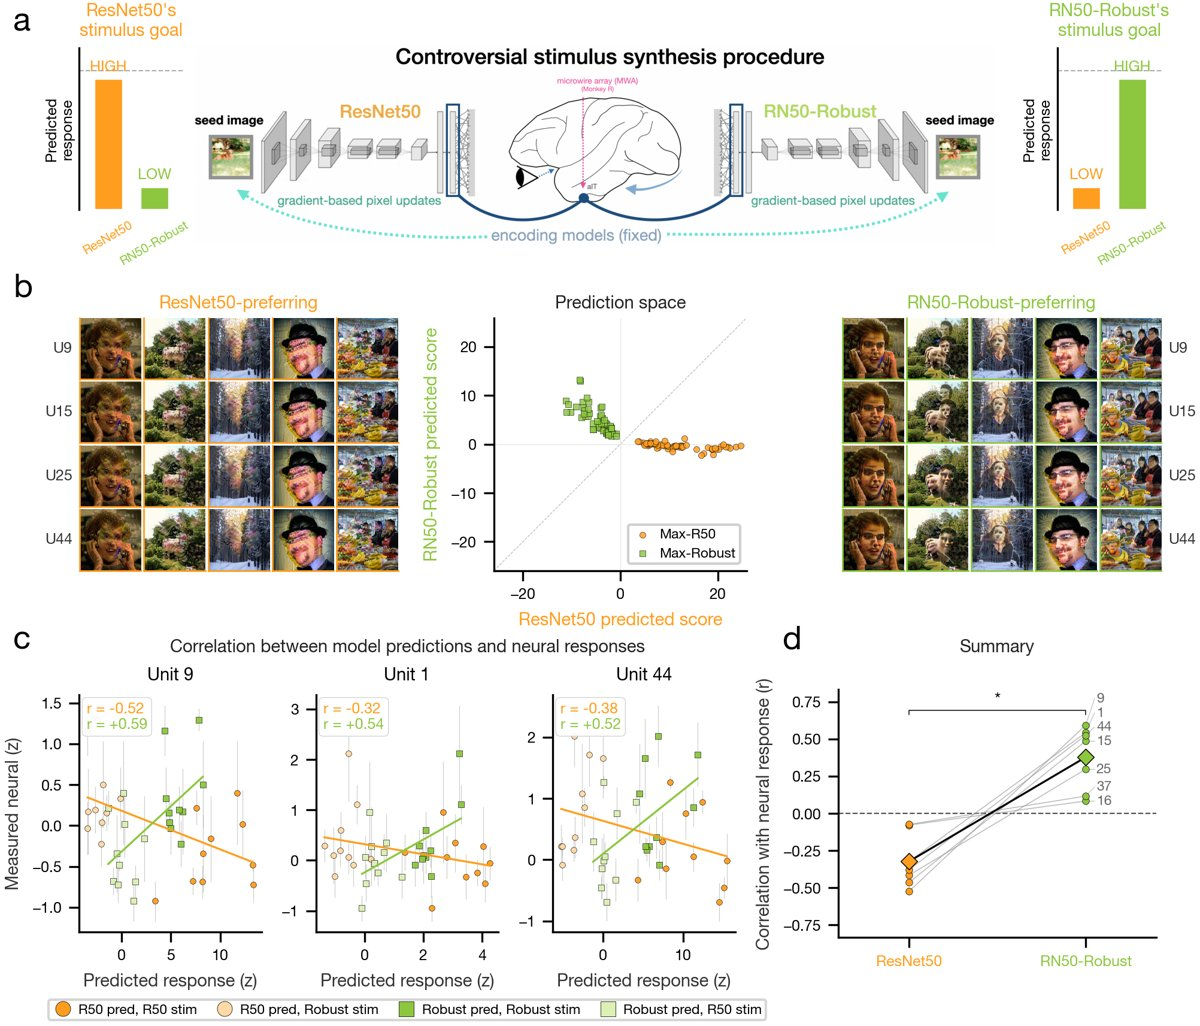

In [14]:
import io
from IPython.display import Image, display
from PIL import Image as PILImage

# A JPEG preview keeps the notebook small; open the PNG for full detail.
print(png)
im = PILImage.open(png).convert("RGB")
im.thumbnail((1200, 1200))
buf = io.BytesIO(); im.save(buf, "JPEG", quality=85, optimize=True)
display(Image(data=buf.getvalue(), format="jpeg", width=900))

**Supplementary Figure S36. Controversial-accentuation experiment.** (A) Procedure for synthesizing controversial stimuli. For each neural site, ResNet50 and ResNet50-Robust encoding models define separate prediction axes. ResNet50-preferring stimuli were optimized for high predicted responses under ResNet50 and low predicted responses under ResNet50-Robust, and ResNet50-Robust-preferring stimuli were optimized for the reverse pattern. (B) Example controversial accentuations for four aIT sites. ResNet50-preferring stimuli are shown at left, and ResNet50-Robust-preferring stimuli at right. The center plot shows the prediction space for one example site, with each stimulus plotted according to its predicted response under ResNet50 and ResNet50-Robust; orange circles indicate ResNet50-preferring stimuli, and green squares indicate ResNet50-Robust-preferring stimuli. (C) Relationship between model predictions and neural responses for three example aIT sites. Neural responses are in standardized firing rate units, and Pearson correlations are shown for each model evaluated on its predictions over both models' preferred stimuli. (D) Summary across the seven targeted aIT sites. Each dot indicates the Pearson correlation between one site's observed responses and predictions from ResNet50 or ResNet50-Robust, evaluated over both groups of stimuli ($20$ stimuli per site); diamonds indicate across-site means, and gray lines connect paired correlations within a site (Wilcoxon signed-rank test). ResNet50-Robust predictions correlate positively with neural responses, whereas ResNet50 predictions generally correlate negatively.